# Ejercicio 3 - Práctica 5

El archivo `202207_PAX15min-ABC.csv` contiene información sobre la cantidad de pasajeros por molinete y por estación en rangos de a 15 minutos de las líneas A, B y C de la red de Subtes de la Ciudad Autónoma de Buenos Aires (CABA).

1. Realice el binning de la variable que corresponde a la hora inicial del intervalo de 15 minutos (columna `DESDE`) en los siguientes periodos a lo largo del día: de 5-9 hs., 9.15-12 hs., 12.15-15 hs., 15.15 - 18 hs., 18.15-21 hs., 21.15 -24 hs. Luego, represente gráficamente el total de pasajeros para cada día en cada rango horario y para cada una de las líneas de subte (un gráfico para cada línea de subte por separado). ¿Hay algún rango horario en el que, en general, se observen más pasajeros respecto de otros rangos? ¿Presentan un comportamiento similar las 3 líneas de subte respecto a la cantidad total de pasajeros en cada rango horario?

2. Para cada línea, analice si los datos muestran alguna diferencia respecto de la cantidad total de pasajeros por rango horario entre días de semana (lunes a viernes) y fines de semana (sábado y domingo). Para ello, puede utilizar `weekday()` de la librería `datetime`, que indica los días de la semana con un número entero (0 para lunes y 6 para domingo, por ejemplo).

3. Finalmente, consideraremos períodos de tiempo semanales sólo teniendo en cuenta los días hábiles:

    Semana 1: 4 al 8 Julio 2022

    Semana 2: 11 al 15 Julio 2022

    Semana 3: 18 al 22 Julio 2022

    Semana 4: 25 al 29 Julio 2022

    Teniendo en cuenta que las semanas 3 y 4 corresponden a las semanas de vacaciones de invierno en CABA, ¿se observa alguna diferencia en la cantidad de pasajeros totales en los distintos rangos horarios en cada línea para estas semanas respecto a las 2 primeras?

---

## Cargamos el dataset

In [12]:
# Cargamos los paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import MinMaxScaler

In [13]:
data = pd.read_csv('../../datasets/202207_PAX15min-ABC.csv', encoding='latin1')
data.head()

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,pax_pagos,pax_pases_pagos,pax_franq,pax_TOTAL
0,01-07-22,5:15:00,5:30:00,LineaA,LineaA_Acoyte_N_Turn06,Acoyte,1,0,0,1
1,01-07-22,5:15:00,5:30:00,LineaA,LineaA_Flores_Este_Turn03,Flores,1,0,0,1
2,01-07-22,5:15:00,5:30:00,LineaA,LineaA_Lima_N_Turn01,Lima,1,0,0,1
3,01-07-22,5:15:00,5:30:00,LineaA,LineaA_Peru_S_Turn03,Peru,1,0,0,1
4,01-07-22,5:15:00,5:30:00,LineaA,LineaA_PJunta_N_Turn01,Primera Junta,1,0,0,1


In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 589934 entries, 0 to 589933
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   FECHA            589934 non-null  str  
 1   DESDE            589934 non-null  str  
 2   HASTA            589934 non-null  str  
 3   LINEA            589934 non-null  str  
 4   MOLINETE         589934 non-null  str  
 5   ESTACION         589934 non-null  str  
 6   pax_pagos        589934 non-null  int64
 7   pax_pases_pagos  589934 non-null  int64
 8   pax_franq        589934 non-null  int64
 9   pax_TOTAL        589934 non-null  int64
dtypes: int64(4), str(6)
memory usage: 45.0 MB


## Item 1

Realice el binning de la variable que corresponde a la hora inicial del intervalo de 15 minutos (columna `DESDE`) en los siguientes periodos a lo largo del día: de 5-9 hs., 9.15-12 hs., 12.15-15 hs., 15.15 - 18 hs., 18.15-21 hs., 21.15 -24 hs. Luego, represente gráficamente el total de pasajeros para cada día en cada rango horario y para cada una de las líneas de subte (un gráfico para cada línea de subte por separado). ¿Hay algún rango horario en el que, en general, se observen más pasajeros respecto de otros rangos? ¿Presentan un comportamiento similar las 3 líneas de subte respecto a la cantidad total de pasajeros en cada rango horario?


In [15]:
data['FECHA'] = pd.to_datetime(data['FECHA'], format='%d-%m-%y')
data['hora_decimal'] = pd.to_datetime(data['DESDE'], format='%H:%M:%S').dt.hour + \
                        pd.to_datetime(data['DESDE'], format='%H:%M:%S').dt.minute / 60

# Definimos los bins y las etiquetas
bins = [5, 9.15, 12.15, 15.15, 18.15, 21.15, 24]
labels = ['05-09', '09.15-12', '12.15-15', '15.15-18', '18.15-21', '21.15-24']

data['RANGO_HORARIO'] = pd.cut(data['hora_decimal'], bins=bins, labels=labels, include_lowest=True)
data.head()

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,pax_pagos,pax_pases_pagos,pax_franq,pax_TOTAL,hora_decimal,RANGO_HORARIO
0,2022-07-01,5:15:00,5:30:00,LineaA,LineaA_Acoyte_N_Turn06,Acoyte,1,0,0,1,5.25,05-09
1,2022-07-01,5:15:00,5:30:00,LineaA,LineaA_Flores_Este_Turn03,Flores,1,0,0,1,5.25,05-09
2,2022-07-01,5:15:00,5:30:00,LineaA,LineaA_Lima_N_Turn01,Lima,1,0,0,1,5.25,05-09
3,2022-07-01,5:15:00,5:30:00,LineaA,LineaA_Peru_S_Turn03,Peru,1,0,0,1,5.25,05-09
4,2022-07-01,5:15:00,5:30:00,LineaA,LineaA_PJunta_N_Turn01,Primera Junta,1,0,0,1,5.25,05-09


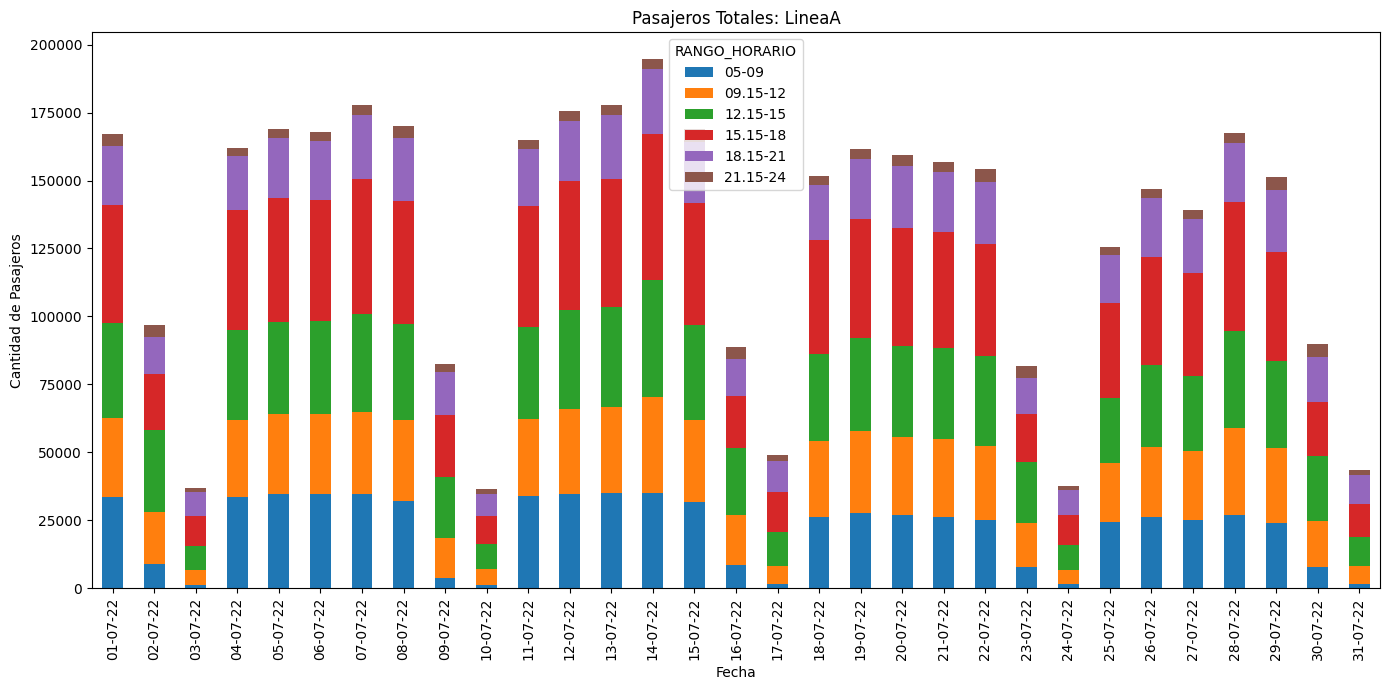

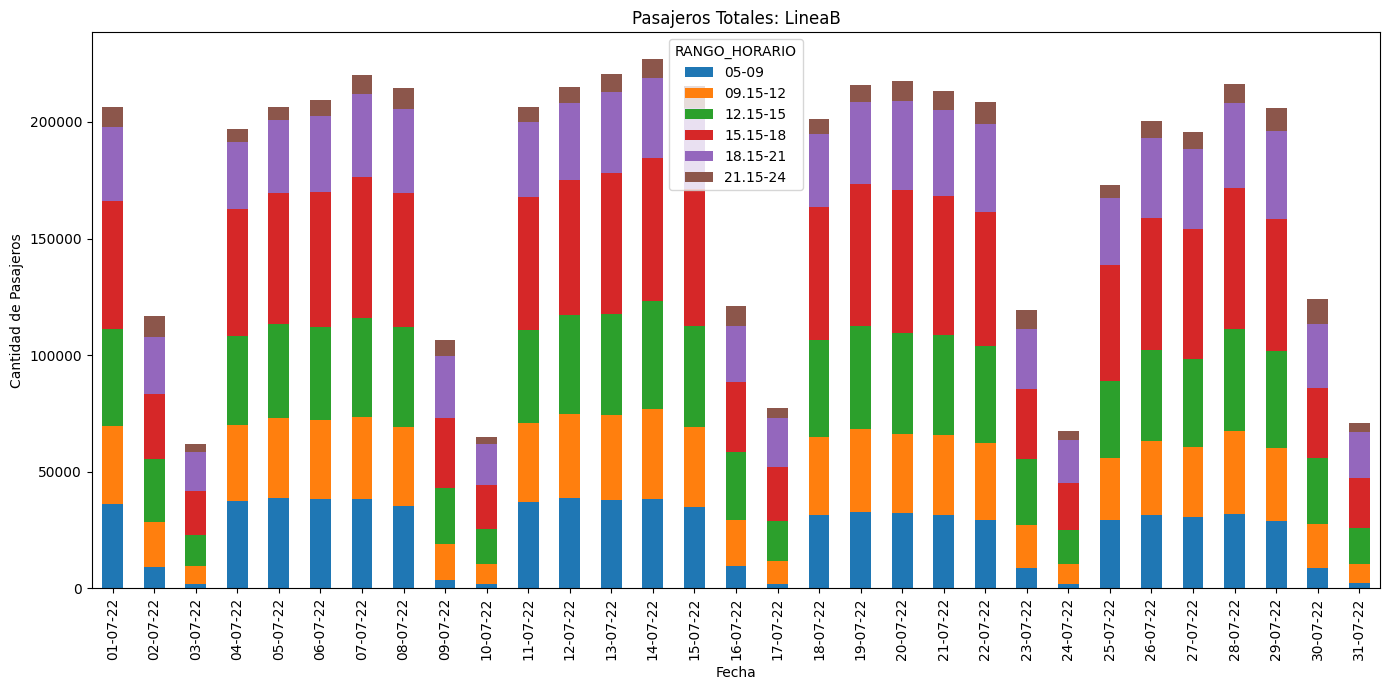

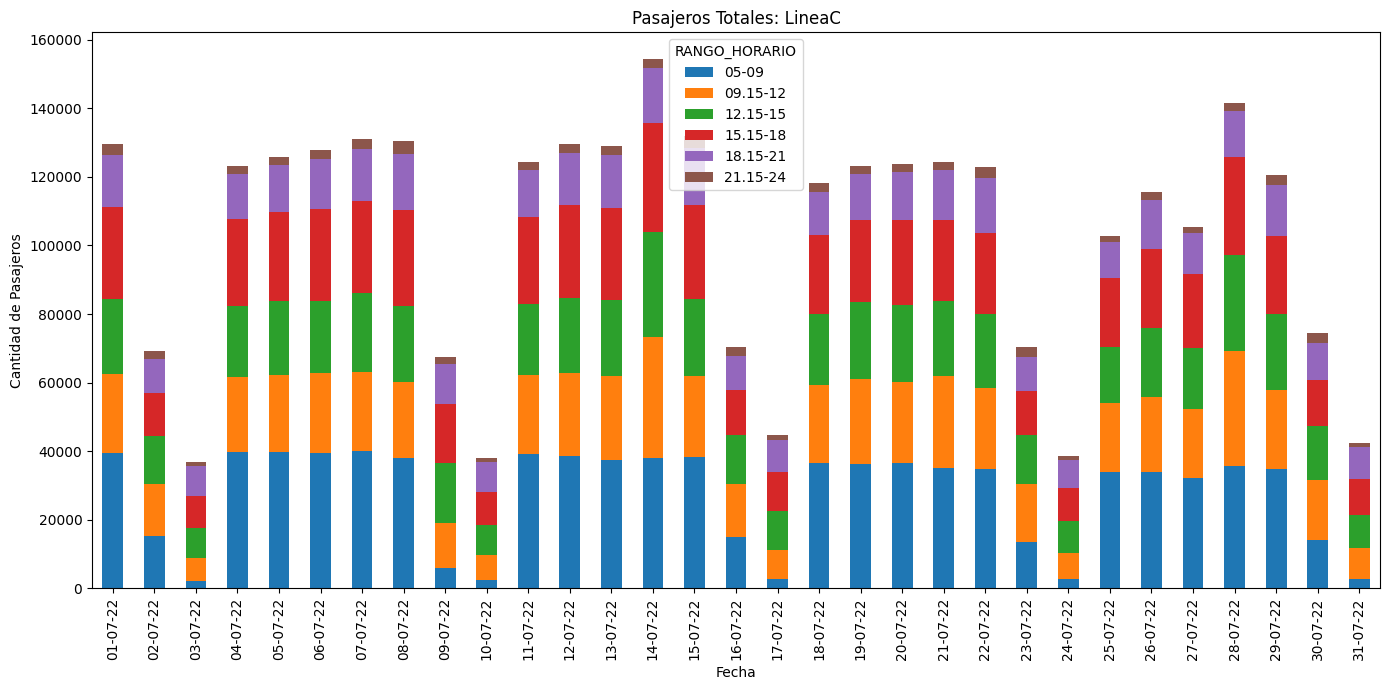

In [22]:
for linea in lineas:
    # Agrupamos
    subset = data[data['LINEA'] == linea].groupby(['FECHA', 'RANGO_HORARIO'])['pax_TOTAL'].sum().unstack()
    
    # Convertimos el índice (FECHA) a string antes de graficar
    subset.index = subset.index.strftime('%d-%m-%y')
    
    # Graficamos
    subset.plot(kind='bar', stacked=True, figsize=(14, 7), title=f'Pasajeros Totales: {linea}')
    
    plt.ylabel('Cantidad de Pasajeros')
    plt.xlabel('Fecha')
    plt.tight_layout()
    plt.show()


## Item 2

Para cada línea, analice si los datos muestran alguna diferencia respecto de la cantidad total de pasajeros por rango horario entre días de semana (lunes a viernes) y fines de semana (sábado y domingo). Para ello, puede utilizar `weekday()` de la librería `datetime`, que indica los días de la semana con un número entero (0 para lunes y 6 para domingo, por ejemplo).

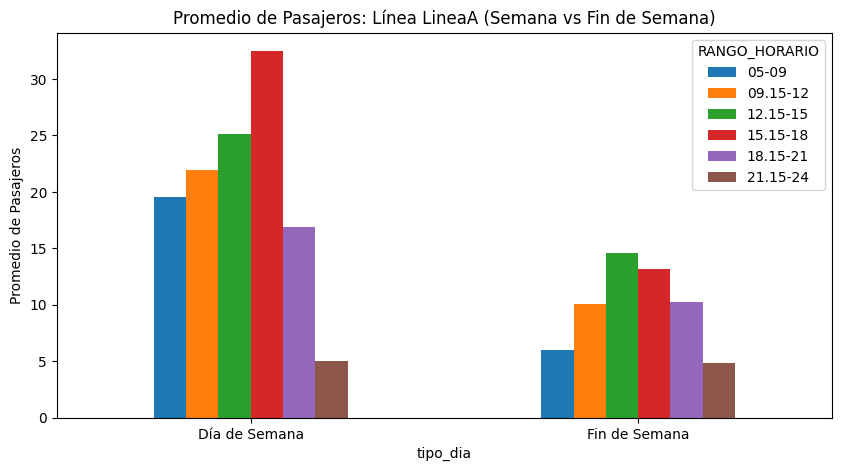

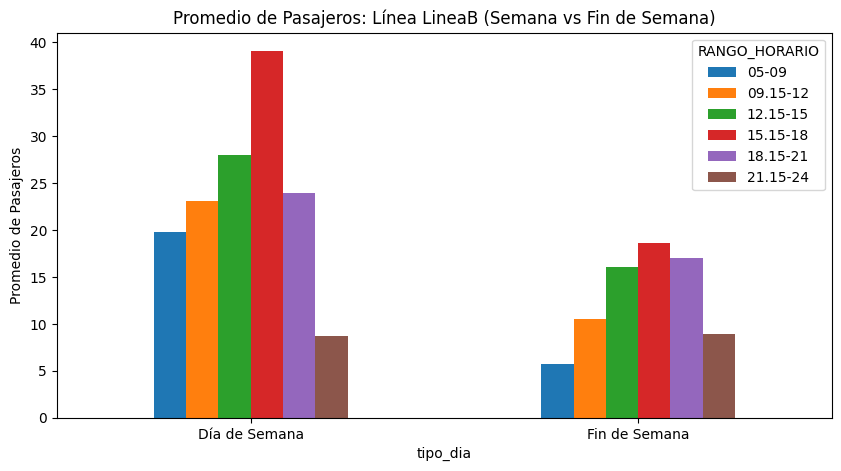

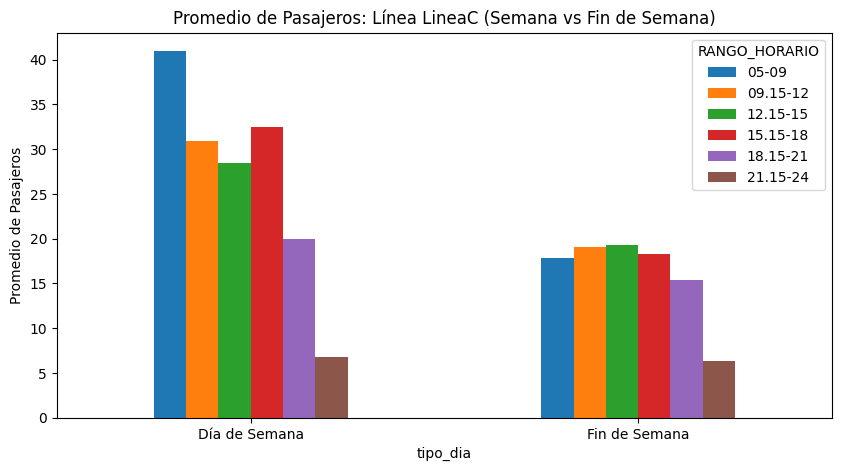

In [28]:
# Creamos la columna para clasificar días de semana vs. fin de semana
data['tipo_dia'] = data['FECHA'].dt.weekday.apply(lambda x: 'Fin de Semana' if x >= 5 else 'Día de Semana')

# Agrupamos por línea, tipo de día y rango horario para obtener el promedio de pasajeros
analisis_comparativo = data.groupby(['LINEA', 'tipo_dia', 'RANGO_HORARIO'])['pax_TOTAL'].mean().unstack()

# Generamos gráficos comparativos para cada línea
for linea in data['LINEA'].unique():
    subset = analisis_comparativo.loc[linea]
    subset.plot(kind='bar', figsize=(10, 5), title=f'Promedio de Pasajeros: Línea {linea} (Semana vs Fin de Semana)')
    plt.ylabel('Promedio de Pasajeros')
    plt.xticks(rotation=0)
    plt.show()

## Item 3

Finalmente, consideraremos períodos de tiempo semanales sólo teniendo en cuenta los días hábiles:

Semana 1: 4 al 8 Julio 2022

Semana 2: 11 al 15 Julio 2022

Semana 3: 18 al 22 Julio 2022

Semana 4: 25 al 29 Julio 2022

Teniendo en cuenta que las semanas 3 y 4 corresponden a las semanas de vacaciones de invierno en CABA, ¿se observa alguna diferencia en la cantidad de pasajeros totales en los distintos rangos horarios en cada línea para estas semanas respecto a las 2 primeras?

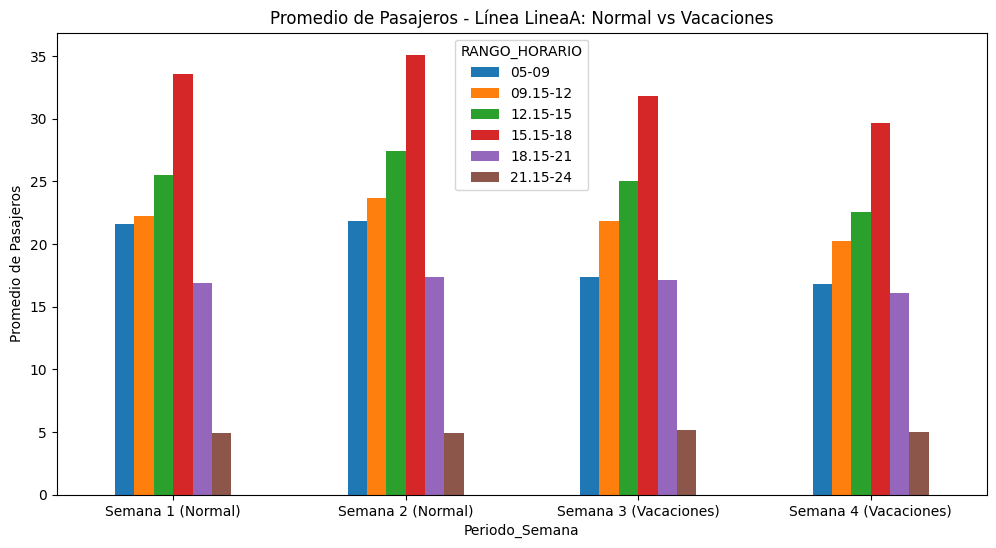

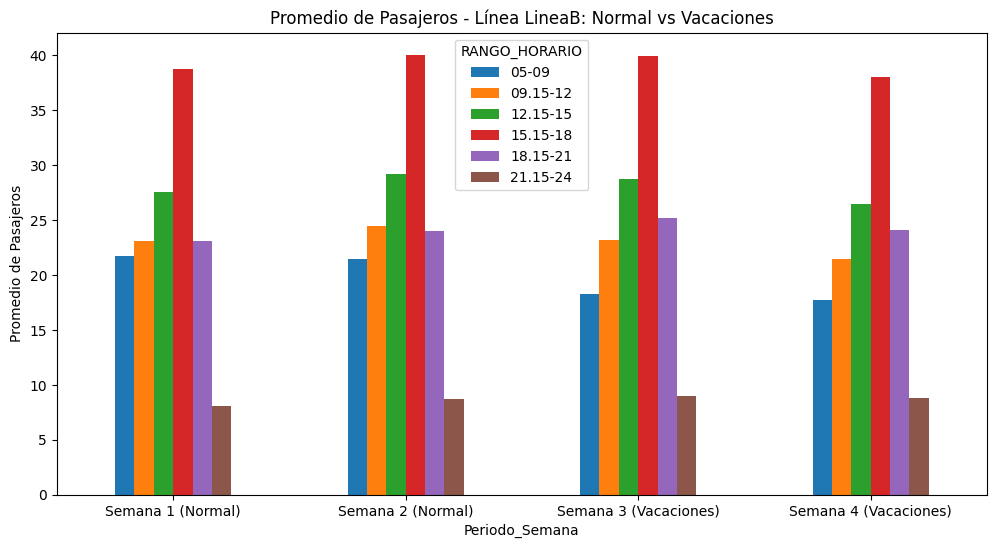

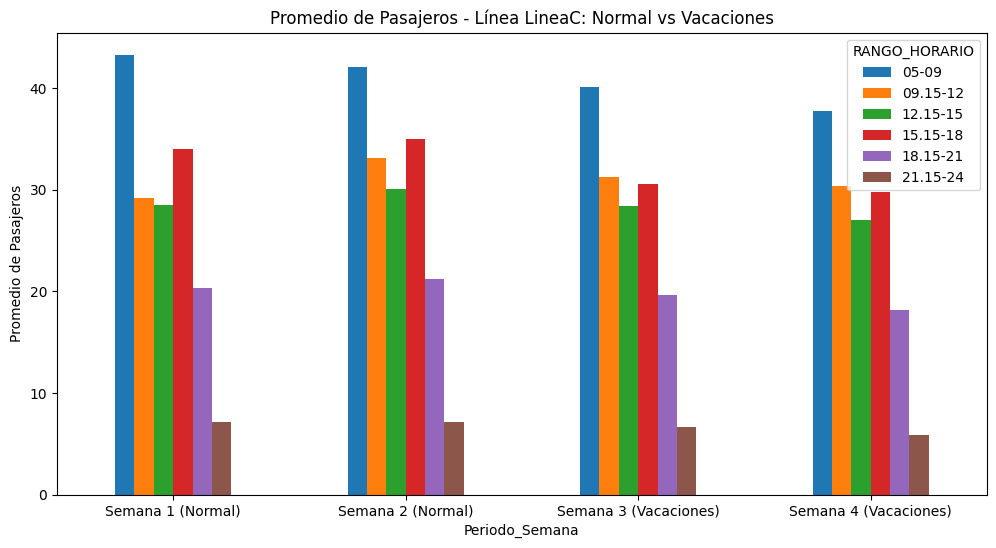

In [30]:
# Definimos los periodos de las semanas hábiles
# Filtramos solo días hábiles
df_habiles = data[data['FECHA'].dt.weekday < 5].copy()

# Creamos una etiqueta para cada semana
def categorizar_semana(fecha):
    if '2022-07-04' <= str(fecha.date()) <= '2022-07-08': return 'Semana 1 (Normal)'
    if '2022-07-11' <= str(fecha.date()) <= '2022-07-15': return 'Semana 2 (Normal)'
    if '2022-07-18' <= str(fecha.date()) <= '2022-07-22': return 'Semana 3 (Vacaciones)'
    if '2022-07-25' <= str(fecha.date()) <= '2022-07-29': return 'Semana 4 (Vacaciones)'
    return None

df_habiles['Periodo_Semana'] = df_habiles['FECHA'].apply(categorizar_semana)
df_habiles = df_habiles.dropna(subset=['Periodo_Semana'])

# Agrupamos por línea, periodo y rango horario
resumen_vacaciones = df_habiles.groupby(['LINEA', 'Periodo_Semana', 'RANGO_HORARIO'])['pax_TOTAL'].mean().unstack()

for linea in df_habiles['LINEA'].unique():
    subset = resumen_vacaciones.loc[linea]
    subset.plot(kind='bar', figsize=(12, 6), title=f'Promedio de Pasajeros - Línea {linea}: Normal vs Vacaciones')
    plt.ylabel('Promedio de Pasajeros')
    plt.xticks(rotation=0)
    plt.show()